# Comparative Statistical Analysis in Python

This notebook compares three numerical datasets using exploratory data analysis, descriptive statistics, correlation, simple linear regression, R-squared, scatterplots, and boxplots.

The aim is to show why visualisation is important when interpreting statistical results, especially when datasets contain non-linear patterns that correlation and regression may not fully capture.


## 1. Import Libraries

The libraries below are used for data handling, numerical calculations, and visualisation.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Load the Dataset

This section loads the dataset into a pandas DataFrame so that it can be inspected and analysed.


In [7]:
df1 = pd.read_csv("../data/dataset1.csv")

print("First 5 rows:")
print(df1.head())

print("\nShape of dataset:")
print(df1.shape)

print("\nColumn names:")
print(df1.columns)

print("\nMissing values in each column:")
print(df1.isna().sum())


First 5 rows:
          x         y
0  0.973963 -9.944776
1  3.253259 -9.376100
2  4.022503 -8.997546
3  9.074710 -4.353142
4  3.673275 -9.482824

Shape of dataset:
(145, 2)

Column names:
Index(['x', 'y'], dtype='str')

Missing values in each column:
x    0
y    3
dtype: int64


### Dataset 1 — Data inspection conclusion

The dataset contains two variables, `x` and `y`, so the analysis will focus on the relationship between these two numerical variables. The inspection also shows whether missing values are present, which is important because incomplete rows must be handled before carrying out descriptive statistics, correlation, or regression.


### Dataset 1 — Missing values and cleaning

The dataset contains missing values, so these need to be handled before further analysis. In this notebook, I use omission by removing rows with missing values. This is a simple and transparent choice because it avoids introducing artificial values into the dataset.


In [8]:
df1_clean = df1.dropna()

print("Original shape:", df1.shape)
print("Cleaned shape:", df1_clean.shape)

print("\nMissing values after cleaning:")
print(df1_clean.isna().sum())


Original shape: (145, 2)
Cleaned shape: (142, 2)

Missing values after cleaning:
x    0
y    0
dtype: int64


### Dataset 1 — Missing values conclusion

After removing rows with missing values, the cleaned dataset is complete and suitable for further analysis. All later calculations for Dataset 1 will therefore be based on the cleaned data.


### Dataset 1 — Scatterplot

A scatterplot is used here to visualise the relationship between `x` and `y`. This is helpful before calculating correlation or regression because it gives an initial view of the overall shape of the data and whether a linear pattern seems reasonable.


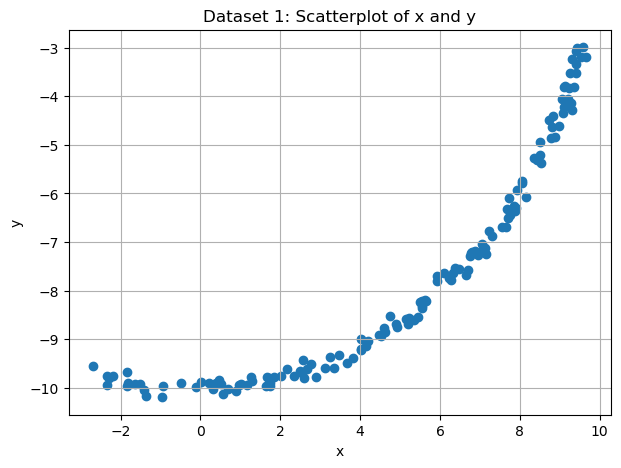

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(df1_clean["x"], df1_clean["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset 1: Scatterplot of x and y")
plt.grid(True)
plt.show()


### Dataset 1 — Scatterplot conclusion

The scatterplot shows a clear positive relationship between `x` and `y`, because larger values of `x` are generally associated with larger values of `y`. However, the pattern does not look perfectly linear. Instead, it appears curved upward, which suggests that the relationship may be non-linear. This is important because correlation and simple linear regression are designed mainly to describe linear relationships, so later results will need to be interpreted with caution.


### Dataset 1 — Descriptive statistics

In this step, I calculate descriptive statistics for the cleaned dataset. These measures help describe the centre and spread of the variables `x` and `y`.

The sample mean is calculated using the arithmetic mean formula:

\[
ar{a} = rac{1}{n}\sum_{i=1}^{n} a_i
\]

The sample variance is calculated using:

\[
s^2 = rac{1}{n-1}\sum_{i=1}^{n}(a_i - ar{a})^2
\]

and the sample standard deviation is:

\[
s = \sqrt{s^2}
\]

I also calculate the median and range to describe the location and spread of the data before moving to correlation and regression.


In [10]:
x1 = df1_clean["x"].tolist()
y1 = df1_clean["y"].tolist()

def manual_mean(values):
    return sum(values) / len(values)

def manual_median(values):
    sorted_values = sorted(values)
    n = len(sorted_values)
    
    if n % 2 == 1:
        middle_index = n // 2
        return sorted_values[middle_index]
    else:
        middle1 = sorted_values[n // 2 - 1]
        middle2 = sorted_values[n // 2]
        return (middle1 + middle2) / 2

def manual_range(values):
    return max(values) - min(values)

def manual_sample_variance(values):
    mean_value = manual_mean(values)
    squared_differences = []
    
    for value in values:
        squared_difference = (value - mean_value) ** 2
        squared_differences.append(squared_difference)
    
    return sum(squared_differences) / (len(values) - 1)

def manual_sample_std(values):
    variance_value = manual_sample_variance(values)
    return variance_value ** 0.5

print("Dataset 1 descriptive statistics")
print("--------------------------------")
print("Number of observations:", len(x1))

print("\nFor x:")
print("Mean =", manual_mean(x1))
print("Median =", manual_median(x1))
print("Range =", manual_range(x1))
print("Sample variance =", manual_sample_variance(x1))
print("Sample standard deviation =", manual_sample_std(x1))

print("\nFor y:")
print("Mean =", manual_mean(y1))
print("Median =", manual_median(y1))
print("Range =", manual_range(y1))
print("Sample variance =", manual_sample_variance(y1))
print("Sample standard deviation =", manual_sample_std(y1))


Dataset 1 descriptive statistics
--------------------------------
Number of observations: 142

For x:
Mean = 4.804523068187054
Median = 5.470291663204533
Range = 12.354518731556263
Sample variance = 12.766293304277726
Sample standard deviation = 3.5729950047932793

For y:
Mean = -7.706230245147192
Median = -8.438341403078287
Range = 7.209556544941453
Sample variance = 4.967406892103435
Sample standard deviation = 2.2287680211505716


### Dataset 1 — Descriptive statistics conclusion

The descriptive statistics summarise the centre and spread of the variables `x` and `y`. The mean and median help show the central location of the data, while the range, sample variance, and sample standard deviation show how spread out the values are.

These results are useful because they give a numerical summary of Dataset 1 before moving to relationship-based methods such as correlation and regression. Since the scatterplot already suggested a curved pattern, these descriptive measures should be interpreted together with the visual pattern rather than on their own.


### Dataset 1 — Boxplot and quartiles

In this step, I calculate the quartiles and the interquartile range (IQR), and then use them to create boxplots for `x` and `y`.

The median is the second quartile \(Q_2\). The lower quartile \(Q_1\) is the median of the lower half of the ordered data, and the upper quartile \(Q_3\) is the median of the upper half of the ordered data. The interquartile range is calculated as:

\[
IQR = Q_3 - Q_1
\]

The boxplot is based on the five-number summary: minimum, \(Q_1\), median, \(Q_3\), and maximum. I also use the 1.5 IQR rule to identify possible outliers.


In [11]:
def manual_quartiles(values):
    sorted_values = sorted(values)
    n = len(sorted_values)

    # median
    if n % 2 == 1:
        median = sorted_values[n // 2]
        lower_half = sorted_values[:n // 2]
        upper_half = sorted_values[n // 2 + 1:]
    else:
        middle1 = sorted_values[n // 2 - 1]
        middle2 = sorted_values[n // 2]
        median = (middle1 + middle2) / 2
        lower_half = sorted_values[:n // 2]
        upper_half = sorted_values[n // 2:]

    # Q1
    n_lower = len(lower_half)
    if n_lower % 2 == 1:
        q1 = lower_half[n_lower // 2]
    else:
        q1 = (lower_half[n_lower // 2 - 1] + lower_half[n_lower // 2]) / 2

    # Q3
    n_upper = len(upper_half)
    if n_upper % 2 == 1:
        q3 = upper_half[n_upper // 2]
    else:
        q3 = (upper_half[n_upper // 2 - 1] + upper_half[n_upper // 2]) / 2

    return q1, median, q3

def five_number_summary(values):
    sorted_values = sorted(values)
    q1, median, q3 = manual_quartiles(values)
    minimum = sorted_values[0]
    maximum = sorted_values[-1]
    return minimum, q1, median, q3, maximum

def iqr_and_outliers(values):
    minimum, q1, median, q3, maximum = five_number_summary(values)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = []
    for value in values:
        if value < lower_bound or value > upper_bound:
            outliers.append(value)

    return iqr, lower_bound, upper_bound, outliers

# x summaries
x1_summary = five_number_summary(x1)
x1_iqr, x1_lower, x1_upper, x1_outliers = iqr_and_outliers(x1)

# y summaries
y1_summary = five_number_summary(y1)
y1_iqr, y1_lower, y1_upper, y1_outliers = iqr_and_outliers(y1)

print("Dataset 1 — Quartiles and boxplot summary")
print("-----------------------------------------")

print("\nFor x:")
print("Minimum =", x1_summary[0])
print("Q1 =", x1_summary[1])
print("Median =", x1_summary[2])
print("Q3 =", x1_summary[3])
print("Maximum =", x1_summary[4])
print("IQR =", x1_iqr)
print("Lower outlier bound =", x1_lower)
print("Upper outlier bound =", x1_upper)
print("Possible outliers =", x1_outliers)

print("\nFor y:")
print("Minimum =", y1_summary[0])
print("Q1 =", y1_summary[1])
print("Median =", y1_summary[2])
print("Q3 =", y1_summary[3])
print("Maximum =", y1_summary[4])
print("IQR =", y1_iqr)
print("Lower outlier bound =", y1_lower)
print("Upper outlier bound =", y1_upper)
print("Possible outliers =", y1_outliers)


Dataset 1 — Quartiles and boxplot summary
-----------------------------------------

For x:
Minimum = -2.6840526741459385
Q1 = 1.7407084858388064
Median = 5.470291663204533
Q3 = 7.877103597926734
Maximum = 9.670466057410325
IQR = 6.136395112087928
Lower outlier bound = -7.463884182293085
Upper outlier bound = 17.081696266058625
Possible outliers = []

For y:
Minimum = -10.198031575336366
Q1 = -9.759008737621029
Median = -8.438341403078287
Q3 = -6.257444393900045
Maximum = -2.988475030394913
IQR = 3.5015643437209842
Lower outlier bound = -15.011355253202506
Upper outlier bound = -1.0050978783185682
Possible outliers = []


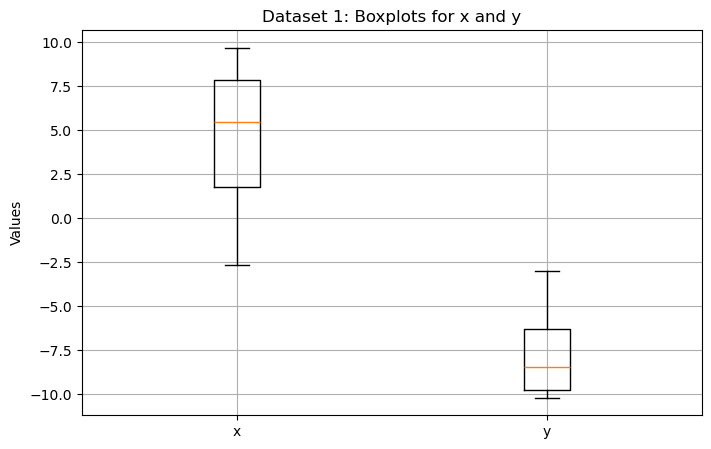

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot([x1, y1], tick_labels=["x", "y"])
plt.title("Dataset 1: Boxplots for x and y")
plt.ylabel("Values")
plt.grid(True)
plt.show()


### Dataset 1 — Boxplot and quartiles conclusion

The quartiles and boxplots give a clearer view of the spread and shape of the variables `x` and `y`. For both variables, the IQR shows the spread of the middle 50% of the data, and the 1.5 IQR rule does not identify any possible outliers. This suggests that the pattern seen earlier is not being caused by a few extreme observations.

The boxplots therefore support the earlier descriptive statistics and show that Dataset 1 has substantial spread but no strong outlier problem. This is useful before moving to correlation and regression, because it suggests that any relationship found between `x` and `y` is likely to reflect the overall data pattern rather than a small number of unusual points.


### Dataset 1 — Correlation

In this step, I calculate the Pearson correlation coefficient between `x` and `y`. Pearson correlation measures the strength and direction of a linear relationship between two variables.

The formula used is:

\[
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}
\]

A value of \(r\) close to 1 suggests a strong positive linear relationship, a value close to -1 suggests a strong negative linear relationship, and a value close to 0 suggests little or no linear relationship.

However, this measure focuses on linear patterns, so it must be interpreted together with the scatterplot.


In [13]:
def manual_correlation(x_values, y_values):
    x_mean = manual_mean(x_values)
    y_mean = manual_mean(y_values)

    numerator = 0
    x_part = 0
    y_part = 0

    for i in range(len(x_values)):
        x_diff = x_values[i] - x_mean
        y_diff = y_values[i] - y_mean

        numerator = numerator + (x_diff * y_diff)
        x_part = x_part + (x_diff ** 2)
        y_part = y_part + (y_diff ** 2)

    denominator = (x_part * y_part) ** 0.5
    r = numerator / denominator
    return r

r1 = manual_correlation(x1, y1)

print("Dataset 1 — Pearson correlation")
print("-------------------------------")
print("Correlation coefficient r =", r1)
print("Rounded to 3 decimal places =", round(r1, 3))


Dataset 1 — Pearson correlation
-------------------------------
Correlation coefficient r = 0.895041135612283
Rounded to 3 decimal places = 0.895


### Dataset 1 — Correlation conclusion

The Pearson correlation coefficient for Dataset 1 is \(r = 0.895\), which indicates a strong positive linear association between `x` and `y`. This means that larger values of `x` generally tend to be associated with larger values of `y`.

However, this result should be interpreted together with the scatterplot. The visual pattern looked curved rather than perfectly straight, so although the correlation is strong, it does not mean that the relationship is perfectly linear. Therefore, the correlation is useful as a summary measure, but it does not fully describe the shape of the dataset.


### Dataset 1 — Simple Linear Regression

In this step, I calculate the simple linear regression line for Dataset 1. The aim is to find the straight line that best fits the data using the least-squares approach.

The regression line has the form:

\[
y = ax + b
\]

where \(a\) is the slope and \(b\) is the intercept.

The slope is calculated using:

\[
a = rac{\sum_{i=1}^{n}(x_i-ar{x})(y_i-ar{y})}{\sum_{i=1}^{n}(x_i-ar{x})^2}
\]

and the intercept is calculated using:

\[
b = ar{y} - aar{x}
\]

This method finds the line that minimises the sum of squared vertical residuals between the observed values and the fitted values.


In [14]:
def regression_slope(x_values, y_values):
    x_mean = manual_mean(x_values)
    y_mean = manual_mean(y_values)

    numerator = 0
    denominator = 0

    for i in range(len(x_values)):
        numerator += (x_values[i] - x_mean) * (y_values[i] - y_mean)
        denominator += (x_values[i] - x_mean) ** 2

    return numerator / denominator

def regression_intercept(x_values, y_values):
    a = regression_slope(x_values, y_values)
    x_mean = manual_mean(x_values)
    y_mean = manual_mean(y_values)
    b = y_mean - a * x_mean
    return b

a1 = regression_slope(x1, y1)
b1 = regression_intercept(x1, y1)

print("Dataset 1 — Simple Linear Regression")
print("------------------------------------")
print("Slope a =", a1)
print("Intercept b =", b1)
print("Rounded slope =", round(a1, 3))
print("Rounded intercept =", round(b1, 3))
print("Regression equation: y =", round(a1, 3), "x +", round(b1, 3))


Dataset 1 — Simple Linear Regression
------------------------------------
Slope a = 0.5583100614444778
Intercept b = -10.388643814558117
Rounded slope = 0.558
Rounded intercept = -10.389
Regression equation: y = 0.558 x + -10.389


In [15]:
y1_pred = []

for x in x1:
    predicted_y = a1 * x + b1
    y1_pred.append(predicted_y)

print("First 10 predicted values:")
print(y1_pred[:10])


First 10 predicted values:
[-9.844870675058887, -8.572316627823689, -8.142840007579032, -5.322141838337194, -8.337817158069265, -10.65655406245884, -7.469624663331029, -5.187964841310448, -6.906188917751162, -5.045012498807693]


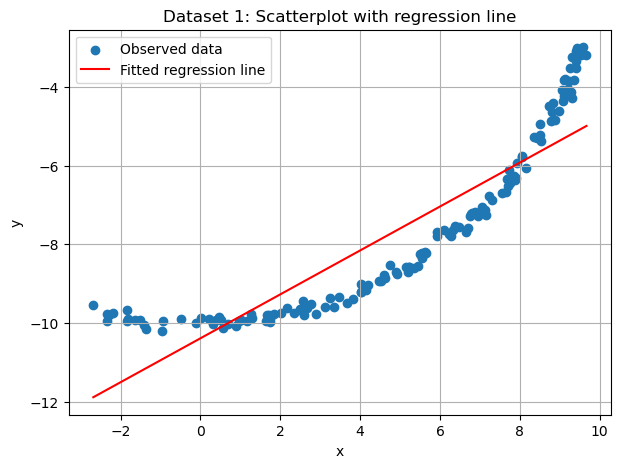

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(x1, y1, label="Observed data")
x1_sorted = sorted(x1)
y1_line = [a1 * xi + b1 for xi in x1_sorted]
plt.plot(x1_sorted, y1_line, color="red", label="Fitted regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset 1: Scatterplot with regression line")
plt.grid(True)
plt.legend()
plt.show()


### Dataset 1 — Simple Linear Regression conclusion

The fitted regression line for Dataset 1 is:

\[
y = 0.558x - 10.389
\]

The positive slope shows that the model predicts larger values of `y` as `x` increases, which agrees with the earlier scatterplot and the positive correlation coefficient.

However, the scatterplot showed that the relationship is curved rather than perfectly straight. This means that the regression line captures the overall upward direction of the relationship, but it does not fully match the shape of the data. Therefore, the linear model is useful as a simple summary, but it should not be treated as a perfect description of Dataset 1.


### Dataset 1 — R-squared

In this step, I calculate the coefficient of determination \(R^2\) for the fitted regression line. This measures how well the regression line explains the variation in the observed `y` values.

The formula used is:

\[
R^2 = 1 - rac{SS_{res}}{SS_{tot}}
\]

where:

- \(SS_{res}\) is the sum of squared residuals
- \(SS_{tot}\) is the total sum of squares

A value of \(R^2 = 1\) means a perfect fit, while \(R^2 = 0\) means the line is no better than simply using the mean of `y`. A higher value suggests a better fit, but it does not automatically mean that the model captures the true shape of the data.


In [17]:
def calculate_ss_res(y_actual, y_predicted):
    ss_res = 0
    for i in range(len(y_actual)):
        ss_res += (y_actual[i] - y_predicted[i]) ** 2
    return ss_res

def calculate_ss_tot(y_actual):
    y_mean = manual_mean(y_actual)
    ss_tot = 0
    for y in y_actual:
        ss_tot += (y - y_mean) ** 2
    return ss_tot

def calculate_r_squared(y_actual, y_predicted):
    ss_res = calculate_ss_res(y_actual, y_predicted)
    ss_tot = calculate_ss_tot(y_actual)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared, ss_res, ss_tot

r2_1, ss_res_1, ss_tot_1 = calculate_r_squared(y1, y1_pred)

print("Dataset 1 — R-squared")
print("---------------------")
print("SS_res =", ss_res_1)
print("SS_tot =", ss_tot_1)
print("R-squared =", r2_1)
print("Rounded R-squared =", round(r2_1, 3))


Dataset 1 — R-squared
---------------------
SS_res = 139.3113859938581
SS_tot = 700.4043717865843
R-squared = 0.801098634438126
Rounded R-squared = 0.801


### Dataset 1 — R-squared conclusion

The coefficient of determination for Dataset 1 is \(R^2 = 0.801\). This means that the fitted linear model explains about 80.1% of the variation in `y`, which suggests that the regression line captures a substantial part of the overall relationship between the variables.

However, this result should still be interpreted together with the scatterplot. The data pattern is clearly curved rather than perfectly straight, so the linear model does not fully represent the true shape of the relationship. Therefore, the \(R^2\) value shows that the line is useful as a summary of the overall upward trend, but it is not a perfect description of Dataset 1.


### Dataset 1 — Final conclusion

The analysis of Dataset 1 shows a clear positive relationship between `x` and `y`. The descriptive statistics and boxplots showed substantial spread in both variables, but no strong evidence of outliers. The scatterplot suggested that the relationship is increasing but curved rather than perfectly linear.

The Pearson correlation coefficient was \(r = 0.895\), which indicates a strong positive linear association. The fitted simple linear regression line was:

\[
y = 0.558x - 10.389
\]

and the coefficient of determination was \(R^2 = 0.801\), meaning that the linear model explains a large proportion of the variation in `y`.

Overall, Dataset 1 does show a strong positive association, and the regression line is useful as a simple summary of the general trend. However, because the scatterplot shows a curved pattern, the relationship is not fully linear, so the regression model should be interpreted with caution.


### Dataset 2 — Data inspection

In this step, I load the second dataset and inspect its structure before carrying out statistical analysis. This is done to understand the variables present, the size of the dataset, and whether there are any missing values that may affect later calculations. This follows the EDA idea of starting with the data first.


In [18]:
df2 = pd.read_csv("../data/dataset2.csv")

print("First 5 rows:")
print(df2.head())

print("\nShape of dataset:")
print(df2.shape)

print("\nColumn names:")
print(df2.columns)

print("\nMissing values in each column:")
print(df2.isna().sum())


First 5 rows:
          x          y
0  8.961704   4.719370
1 -3.448427   9.357161
2 -5.592158  -8.299019
3  0.682621  10.099254
4 -1.901258   9.790234

Shape of dataset:
(287, 2)

Column names:
Index(['x', 'y'], dtype='str')

Missing values in each column:
x    0
y    3
dtype: int64


### Dataset 2 — Missing values and cleaning

The dataset contains missing values, so these need to be handled before further analysis. In this notebook, I use omission by removing rows with missing values. This is a simple and transparent choice because it avoids introducing artificial values into the dataset.


In [19]:
df2_clean = df2.dropna()

print("Original shape:", df2.shape)
print("Cleaned shape:", df2_clean.shape)

print("\nMissing values after cleaning:")
print(df2_clean.isna().sum())


Original shape: (287, 2)
Cleaned shape: (284, 2)

Missing values after cleaning:
x    0
y    0
dtype: int64


### Dataset 2 — Scatterplot

A scatterplot is used here to visualise the relationship between `x` and `y`. This is helpful before calculating correlation or regression because it gives an initial view of the overall shape of the data and whether a linear pattern seems reasonable.


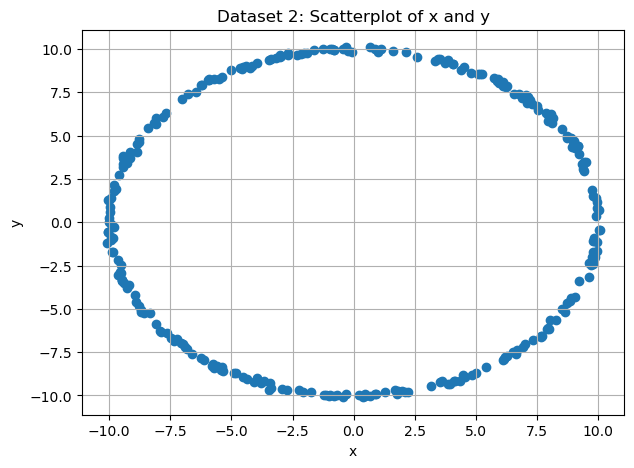

In [20]:
plt.figure(figsize=(7, 5))
plt.scatter(df2_clean["x"], df2_clean["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset 2: Scatterplot of x and y")
plt.grid(True)
plt.show()


### Dataset 2 — Scatterplot conclusion

The scatterplot for Dataset 2 shows a clear circular or elliptical pattern. This means that there is a strong visible relationship between `x` and `y`, but it is not a linear one. Therefore, this dataset is important because it shows that visual inspection is necessary before interpreting correlation or regression results. A linear method may not describe this shape well, even though the variables are clearly related.


### Dataset 2 — Descriptive statistics

In this step, I calculate descriptive statistics for Dataset 2. These measures help describe the centre and spread of the variables `x` and `y` using the sample mean, median, range, sample variance, and sample standard deviation. These statistics provide a numerical summary of the data before moving to quartiles, correlation, and regression.


In [21]:
x2 = df2_clean["x"].tolist()
y2 = df2_clean["y"].tolist()

print("Dataset 2 descriptive statistics")
print("--------------------------------")
print("Number of observations:", len(x2))

print("\nFor x:")
print("Mean =", manual_mean(x2))
print("Median =", manual_median(x2))
print("Range =", manual_range(x2))
print("Sample variance =", manual_sample_variance(x2))
print("Sample standard deviation =", manual_sample_std(x2))

print("\nFor y:")
print("Mean =", manual_mean(y2))
print("Median =", manual_median(y2))
print("Range =", manual_range(y2))
print("Sample variance =", manual_sample_variance(y2))
print("Sample standard deviation =", manual_sample_std(y2))


Dataset 2 descriptive statistics
--------------------------------
Number of observations: 284

For x:
Mean = 0.0030512932486509935
Median = -0.3241868961324622
Range = 20.171140762620965
Sample variance = 49.01514158458388
Sample standard deviation = 7.0010814582165715

For y:
Mean = 0.10399704968445687
Median = 0.14904473754563854
Range = 20.205169766341832
Sample variance = 51.46078804847777
Sample standard deviation = 7.173617500848353


### Dataset 2 — Descriptive statistics conclusion

The descriptive statistics provide a numerical summary of the centre and spread of `x` and `y` in Dataset 2. However, because the scatterplot showed a circular or elliptical pattern, these values should be interpreted together with the visual structure of the dataset. On their own, the descriptive statistics do not capture the full shape of the relationship between the variables.


In [22]:
# x summaries
x2_summary = five_number_summary(x2)
x2_iqr, x2_lower, x2_upper, x2_outliers = iqr_and_outliers(x2)

# y summaries
y2_summary = five_number_summary(y2)
y2_iqr, y2_lower, y2_upper, y2_outliers = iqr_and_outliers(y2)

print("Dataset 2 — Quartiles and boxplot summary")
print("-----------------------------------------")

print("\nFor x:")
print("Minimum =", x2_summary[0])
print("Q1 =", x2_summary[1])
print("Median =", x2_summary[2])
print("Q3 =", x2_summary[3])
print("Maximum =", x2_summary[4])
print("IQR =", x2_iqr)
print("Lower outlier bound =", x2_lower)
print("Upper outlier bound =", x2_upper)
print("Possible outliers =", x2_outliers)

print("\nFor y:")
print("Minimum =", y2_summary[0])
print("Q1 =", y2_summary[1])
print("Median =", y2_summary[2])
print("Q3 =", y2_summary[3])
print("Maximum =", y2_summary[4])
print("IQR =", y2_iqr)
print("Lower outlier bound =", y2_lower)
print("Upper outlier bound =", y2_upper)
print("Possible outliers =", y2_outliers)


Dataset 2 — Quartiles and boxplot summary
-----------------------------------------

For x:
Minimum = -10.107177332073675
Q1 = -6.697392331711951
Median = -0.3241868961324622
Q3 = 7.027765961102479
Maximum = 10.063963430547288
IQR = 13.725158292814431
Lower outlier bound = -27.2851297709336
Upper outlier bound = 27.615503400324126
Possible outliers = []

For y:
Minimum = -10.100035230772418
Q1 = -7.193041934106445
Median = 0.14904473754563854
Q3 = 7.3791912476051635
Maximum = 10.105134535569412
IQR = 14.572233181711608
Lower outlier bound = -29.051391706673854
Upper outlier bound = 29.237541020172575
Possible outliers = []


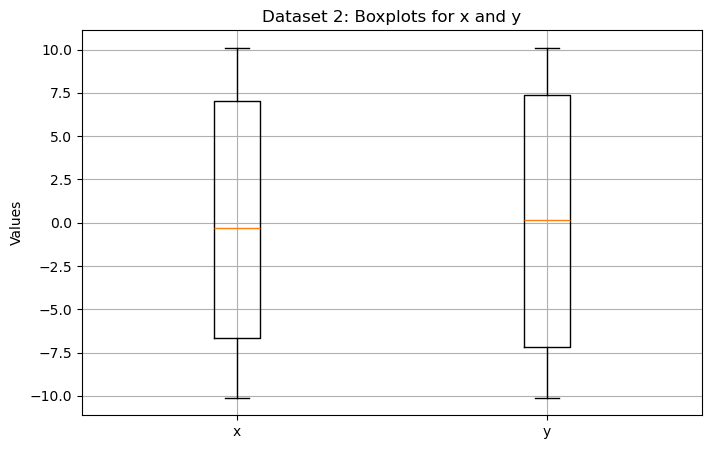

In [23]:
plt.figure(figsize=(8, 5))
plt.boxplot([x2, y2], tick_labels=["x", "y"])
plt.title("Dataset 2: Boxplots for x and y")
plt.ylabel("Values")
plt.grid(True)
plt.show()


### Dataset 2 - Correlation

In this step, I calculate the Pearson correlation coefficient between \(x\) and \(y\) for Dataset 2. This measures the direction and strength of the linear relationship between the two variables.

Pearson correlation takes values between \(-1\) and \(1\). A value close to \(1\) suggests a strong positive linear relationship, a value close to \(-1\) suggests a strong negative linear relationship, and a value close to \(0\) suggests little or no linear relationship.

The formula used is:

\[
r = rac{\sum_{i=1}^{n}(x_i-ar{x})(y_i-ar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-ar{x})^2 \sum_{i=1}^{n}(y_i-ar{y})^2}}
\]

This step is useful because the scatterplot for Dataset 2 shows a clear visible pattern, so correlation helps check whether that pattern is linear or not.


In [24]:
# Dataset 2 - Correlation

x2_values = df2_clean["x"].tolist()
y2_values = df2_clean["y"].tolist()

r_dataset2 = manual_correlation(x2_values, y2_values)

print("Dataset 2 correlation:")
print("r =", r_dataset2)
print("rounded =", round(r_dataset2, 3))


Dataset 2 correlation:
r = 0.05629359205802862
rounded = 0.056


The Pearson correlation coefficient for Dataset 2 is **0.056**, which is very close to **0**. This means there is almost no linear relationship between \(x\) and \(y\).

This is an important result because the scatterplot still shows a clear visible pattern. In other words, the variables appear related, but the relationship is not linear. This demonstrates why correlation alone can be misleading if the scatterplot is not inspected first.


### Dataset 2 - Simple Linear Regression

In this step, I calculate the simple linear regression line for Dataset 2. The purpose is to find the line of best fit in the form:

\[
y = ax + b
\]

where \(a\) is the slope and \(b\) is the intercept.

Simple linear regression uses the least-squares method, which finds the line that minimises the sum of squared vertical differences between the observed \(y\)-values and the predicted values on the line.

The formulas used are:

\[
a = rac{\sum_{i=1}^{n}(x_i-ar{x})(y_i-ar{y})}{\sum_{i=1}^{n}(x_i-ar{x})^2}
\]

\[
b = ar{y} - aar{x}
\]

I calculate this line using the manual functions created earlier in the notebook, rather than relying only on black-box functions. Even though Dataset 2 does not show a linear pattern in the scatterplot, this step helps test whether a straight-line model is suitable.


In [25]:
# Dataset 2 - Simple Linear Regression

x2_values = df2_clean["x"].tolist()
y2_values = df2_clean["y"].tolist()

a2 = regression_slope(x2_values, y2_values)
b2 = regression_intercept(x2_values, y2_values)

print("Dataset 2 simple linear regression:")
print("slope a =", a2)
print("intercept b =", b2)
print("rounded equation: y =", round(a2, 3), "x +", round(b2, 3))


Dataset 2 simple linear regression:
slope a = 0.057680902526730735
intercept b = 0.10382104833600096
rounded equation: y = 0.058 x + 0.104


The simple linear regression line for Dataset 2 is:

\[
y = 0.058x + 0.104
\]

The slope is **positive but very small**, which means that the fitted line shows only a very weak upward trend. This agrees with the earlier correlation result, which was also very close to zero.

However, this regression line does **not** describe the true shape of the data very well. The scatterplot for Dataset 2 showed a **circular or elliptical pattern**, not a straight-line trend. So, although a least-squares regression line can still be calculated, it is **not a very suitable summary** of this dataset.

This again shows why visual inspection is important. A regression line may exist mathematically, but that does not mean it captures the real relationship in the data.


### Dataset 2 - R-squared

In this step, I calculate the \(R^2\) value for Dataset 2. The \(R^2\) value, also called the coefficient of determination, measures how well the regression line explains the variation in the observed \(y\)-values.

The formula is:

\[
R^2 = 1 - rac{SS_{res}}{SS_{tot}}
\]

where

\[
SS_{res} = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

is the residual sum of squares, and

\[
SS_{tot} = \sum_{i=1}^{n}(y_i-ar{y})^2
\]

is the total sum of squares.

An \(R^2\) value close to 1 means the regression line explains much of the variation in the data, while a value close to 0 means the line is not much better than simply using the mean of \(y\).

Since Dataset 2 does not show a linear pattern, I expect the \(R^2\) value to be low, showing that the straight-line model is not a strong fit here.


In [26]:
# Dataset 2 - R-squared

x2_values = df2_clean["x"].tolist()
y2_values = df2_clean["y"].tolist()

y2_predicted = []

for x in x2_values:
    y_hat = a2 * x + b2
    y2_predicted.append(y_hat)

ss_res_2 = calculate_ss_res(y2_values, y2_predicted)
ss_tot_2 = calculate_ss_tot(y2_values)

r_squared_result_2 = calculate_r_squared(y2_values, y2_predicted)
r_squared_2 = r_squared_result_2[0]

print("Dataset 2 R-squared:")
print("SS_res =", ss_res_2)
print("SS_tot =", ss_tot_2)
print("R-squared =", r_squared_2)
print("rounded =", round(r_squared_2, 3))


Dataset 2 R-squared:
SS_res = 14517.252052204283
SS_tot = 14563.403017719207
R-squared = 0.0031689685067955997
rounded = 0.003


The \(R^2\) value for Dataset 2 is **0.003**, which is extremely close to **0**. This means that the simple linear regression line explains almost none of the variation in the \(y\)-values.

So, for Dataset 2, the fitted straight-line model is **not a good representation** of the data. This matches what was already seen in the scatterplot and correlation result. The data clearly had a visible structure, but that structure was **not linear**. As a result, the regression line performs only very slightly better than using the mean of \(y\).

This is a strong example of why a low \(R^2\) value should be interpreted together with the scatterplot. The dataset is not random, but a straight-line model is not suitable for describing its pattern.


### Dataset 2 - conclusion

Dataset 2 shows why it is important to combine numerical measures with visual inspection.

After cleaning, the dataset contained **284 observations** and no missing values. The descriptive statistics and boxplots showed that both variables had a wide spread, but no possible outliers under the 1.5 IQR rule. However, the scatterplot revealed the most important feature of this dataset: the points formed a **clear circular or elliptical pattern**.

The Pearson correlation coefficient was **0.056**, which is very close to zero, showing almost no **linear** relationship between \(x\) and \(y\). The simple linear regression line,

\[
y = 0.058x + 0.104
\]

also showed only a very weak upward trend. In addition, the \(R^2\) value was **0.003**, meaning that the straight-line model explained almost none of the variation in \(y\).

Overall, Dataset 2 clearly contains a visible relationship between the variables, but it is **not a linear relationship**. This means that correlation and simple linear regression are not suitable summaries of the pattern here. The scatterplot is therefore the most informative tool for interpreting Dataset 2.


### Dataset 3 - Data inspection

In this step, I inspect Dataset 3 before carrying out any calculations. This helps me understand the structure of the dataset, the variable names, the number of observations, and whether any missing values are present.

In particular, I check:

- the column names
- the shape of the dataset
- the first few rows
- the number of missing values in each column

This gives a simple overview of the dataset and helps prepare for the next cleaning step.


In [27]:
# Load Dataset 3

df3 = pd.read_csv("../data/dataset3.csv")

print("Dataset 3 loaded successfully")
print(df3.head())


Dataset 3 loaded successfully
           x         y
0   9.530821 -2.426222
1  -1.037527 -9.876796
2   9.880565 -1.646456
3   4.495554  8.668937
4  10.169415  0.306275


In [28]:
# Dataset 3 - Data inspection

print("Dataset 3 columns:")
print(df3.columns)

print("\nDataset 3 shape:")
print(df3.shape)

print("\nFirst 5 rows of Dataset 3:")
print(df3.head())

print("\nMissing values in Dataset 3:")
print(df3.isna().sum())


Dataset 3 columns:
Index(['x', 'y'], dtype='str')

Dataset 3 shape:
(145, 2)

First 5 rows of Dataset 3:
           x         y
0   9.530821 -2.426222
1  -1.037527 -9.876796
2   9.880565 -1.646456
3   4.495554  8.668937
4  10.169415  0.306275

Missing values in Dataset 3:
x    0
y    3
dtype: int64


Dataset 3 contains two variables, **x** and **y**, and has **145 rows** and **2 columns** in total. From the first few rows, both variables appear to be numeric and suitable for scatterplots and numerical summary measures.

The inspection step also shows that there are **3 missing values in the y column**, while the x column has no missing values. This means the dataset needs a cleaning step before further analysis, so that later calculations such as descriptive statistics, correlation, and regression are based only on complete observations.

Overall, Dataset 3 has the expected structure for this analysis, but it requires a small amount of cleaning before moving on.


### Dataset 3 - Missing values and cleaning

Before carrying out further analysis, I handle the missing values in Dataset 3. Missing data can affect plots and statistical calculations, so it is important to deal with it before computing summary measures or fitting a regression line.

In this notebook, I use omission by removing rows that contain missing values. This is a simple and transparent approach because only a small number of rows are incomplete, and it avoids introducing artificial values into the dataset.


In [29]:
# Dataset 3 - Missing values and cleaning

df3_clean = df3.dropna()

print("Original shape:", df3.shape)
print("Cleaned shape:", df3_clean.shape)

print("\nMissing values after cleaning:")
print(df3_clean.isna().sum())


Original shape: (145, 2)
Cleaned shape: (142, 2)

Missing values after cleaning:
x    0
y    0
dtype: int64


After cleaning, Dataset 3 was reduced from **145 rows** to **142 rows**, which means **3 incomplete observations** were removed. The cleaned dataset now has **no missing values** in either variable.

Because only a small number of rows were removed, this is a simple and reasonable cleaning step. It allows the rest of the analysis to be carried out using complete data only, without introducing guessed or artificial values.

So, Dataset 3 is now ready for visualisation and numerical analysis.


### Dataset 3 - Scatterplot

In this step, I create a scatterplot of \(x\) against \(y\) for Dataset 3. A scatterplot is useful because it allows me to visually inspect the relationship between two numeric variables before relying on summary measures such as correlation or regression.

This step helps reveal:

- whether the relationship looks positive or negative
- whether the pattern looks linear or curved
- whether there is a strong or weak association
- whether there are any unusual points

Visual inspection helps decide whether later methods such as correlation and simple linear regression are likely to be appropriate.


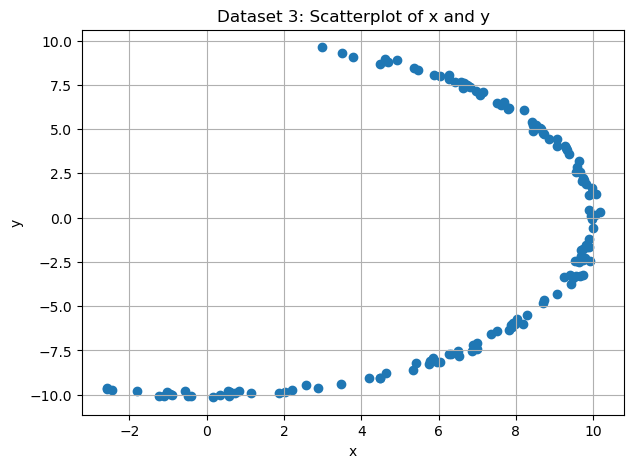

In [30]:
# Dataset 3 - Scatterplot

plt.figure(figsize=(7, 5))
plt.scatter(df3_clean["x"], df3_clean["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset 3: Scatterplot of x and y")
plt.grid(True)
plt.show()


The scatterplot for Dataset 3 shows a **strong curved relationship** between \(x\) and \(y\). The points form a clear arc-like pattern rather than a straight-line trend.

This means there is a visible association between the two variables, but the relationship does **not appear linear**. In particular, the pattern suggests that a straight-line model may not describe the data well, because the points bend around instead of following a roughly straight direction.

So, the scatterplot suggests that visual inspection is very important for Dataset 3. It already indicates that later correlation and simple linear regression results should be interpreted carefully, because the relationship is likely to be non-linear.


### Dataset 3 - Descriptive statistics

In this step, I calculate descriptive statistics for both \(x\) and \(y\) in Dataset 3. These statistics help summarise the centre and spread of the cleaned data.

The analysis includes:

- the mean as a measure of central tendency
- the median as another measure of central tendency
- the range as a simple measure of spread
- the sample variance
- the sample standard deviation

The formulas used are:

Sample mean:

\[
ar{x} = rac{1}{n}\sum_{i=1}^{n} x_i
\]

Range:

\[
	ext{Range} = \max(x) - \min(x)
\]

Sample variance:

\[
s^2 = rac{1}{n-1}\sum_{i=1}^{n}(x_i-ar{x})^2
\]

Sample standard deviation:

\[
s = \sqrt{rac{1}{n-1}\sum_{i=1}^{n}(x_i-ar{x})^2}
\]

The median is found by ordering the values and taking the middle value, or the average of the two middle values if the number of observations is even.

I calculate these manually using the functions created earlier in the notebook to show the logic behind each statistic.


In [31]:
# Dataset 3 - Descriptive statistics

x3_values = df3_clean["x"].tolist()
y3_values = df3_clean["y"].tolist()

print("Dataset 3 descriptive statistics:")
print("Number of observations:", len(x3_values))

print("\nFor x:")
print("Mean =", manual_mean(x3_values))
print("Median =", manual_median(x3_values))
print("Range =", manual_range(x3_values))
print("Sample variance =", manual_sample_variance(x3_values))
print("Sample standard deviation =", manual_sample_std(x3_values))

print("\nFor y:")
print("Mean =", manual_mean(y3_values))
print("Median =", manual_median(y3_values))
print("Range =", manual_range(y3_values))
print("Sample variance =", manual_sample_variance(y3_values))
print("Sample standard deviation =", manual_sample_std(y3_values))


Dataset 3 descriptive statistics:
Number of observations: 142

For x:
Mean = 6.428758178889653
Median = 7.506929306018715
Range = 12.760021702355948
Sample variance = 12.179010688217618
Sample standard deviation = 3.4898439346506054

For y:
Mean = -1.4687826362776668
Median = -2.344339340522266
Range = 19.769749879259106
Sample variance = 44.75867076008628
Sample standard deviation = 6.690192131776657


The descriptive statistics show that Dataset 3 has **142 observations** after cleaning.

For \(x\), the mean is approximately **6.429** and the median is approximately **7.507**. The spread is moderate, with a range of about **12.760** and a sample standard deviation of about **3.490**.

For \(y\), the mean is approximately **-1.469** and the median is approximately **-2.344**. The spread is much larger than for \(x\), with a range of about **19.770** and a sample standard deviation of about **6.690**.

These statistics are useful for summarising the centre and spread of the two variables, but they do not fully describe the curved shape that was already seen in the scatterplot. So, as with the earlier datasets, the descriptive statistics should be interpreted together with the visual pattern rather than on their own.


### Dataset 2 - Boxplot and quartiles

In this step, I calculate the quartiles and five-number summary for both \(x\) and \(y\), and then draw boxplots. This helps describe the distribution of each variable in a more visual way.

A boxplot is based on the five-number summary:

- minimum
- lower quartile \(Q_1\)
- median \(Q_2\)
- upper quartile \(Q_3\)
- maximum

The interquartile range is calculated as:

\[
IQR = Q_3 - Q_1
\]

I also check for possible outliers using the usual 1.5 IQR rule:

\[
	ext{Lower bound} = Q_1 - 1.5(IQR)
\]

\[
	ext{Upper bound} = Q_3 + 1.5(IQR)
\]

This step gives a clearer picture of spread, central position, and possible outliers than mean and standard deviation alone.


Dataset 3 quartiles / boxplot summary:

For x:
Minimum = -2.5906062928593965
Q1 = 4.650012194222722
Median = 7.506929306018715
Q3 = 9.388971185894954
Maximum = 10.169415409496551
IQR = 4.738958991672233
Lower outlier bound = -2.458426293285627
Upper outlier bound = 16.497409673403304
Possible outliers = [-2.5688395561155044, -2.5906062928593965]

For y:
Minimum = -10.144121165237337
Q1 = -8.113527689726729
Median = -2.344339340522266
Q3 = 5.006876997336449
Maximum = 9.625628714021769
IQR = 13.120404687063179
Lower outlier bound = -27.794134720321495
Upper outlier bound = 24.687484027931216
Possible outliers = []


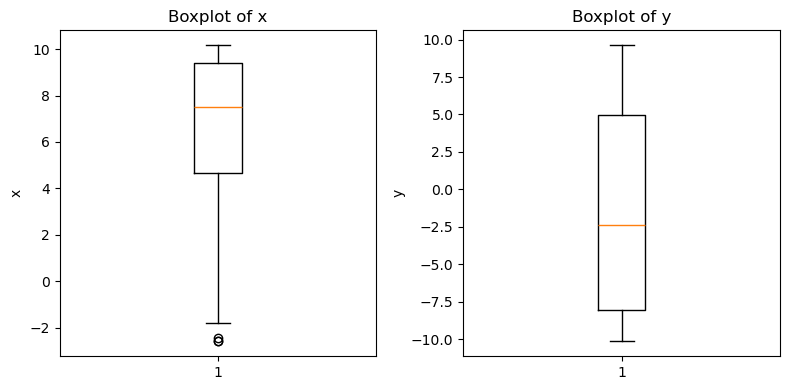

In [32]:
# Dataset 3 - Boxplot and quartiles

x3_values = df3_clean["x"].tolist()
y3_values = df3_clean["y"].tolist()

x3_five_num = five_number_summary(x3_values)
y3_five_num = five_number_summary(y3_values)

x3_iqr_info = iqr_and_outliers(x3_values)
y3_iqr_info = iqr_and_outliers(y3_values)

print("Dataset 3 quartiles / boxplot summary:")

print("\nFor x:")
print("Minimum =", x3_five_num[0])
print("Q1 =", x3_five_num[1])
print("Median =", x3_five_num[2])
print("Q3 =", x3_five_num[3])
print("Maximum =", x3_five_num[4])
print("IQR =", x3_iqr_info[0])
print("Lower outlier bound =", x3_iqr_info[1])
print("Upper outlier bound =", x3_iqr_info[2])
print("Possible outliers =", x3_iqr_info[3])

print("\nFor y:")
print("Minimum =", y3_five_num[0])
print("Q1 =", y3_five_num[1])
print("Median =", y3_five_num[2])
print("Q3 =", y3_five_num[3])
print("Maximum =", y3_five_num[4])
print("IQR =", y3_iqr_info[0])
print("Lower outlier bound =", y3_iqr_info[1])
print("Upper outlier bound =", y3_iqr_info[2])
print("Possible outliers =", y3_iqr_info[3])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df3_clean["x"])
plt.title("Boxplot of x")
plt.ylabel("x")

plt.subplot(1, 2, 2)
plt.boxplot(df3_clean["y"])
plt.title("Boxplot of y")
plt.ylabel("y")

plt.tight_layout()
plt.show()


The boxplots and quartile summaries give a clearer view of the distribution of each variable in Dataset 3.

For \(x\), the five-number summary shows:

- Minimum = **-2.591**
- \(Q_1\) = **4.650**
- Median = **7.507**
- \(Q_3\) = **9.389**
- Maximum = **10.169**

The interquartile range for \(x\) is about **4.739**, and there are **two possible lower outliers** based on the 1.5 IQR rule.

For \(y\), the five-number summary shows:

- Minimum = **-10.144**
- \(Q_1\) = **-8.114**
- Median = **-2.344**
- \(Q_3\) = **5.007**
- Maximum = **9.626**

The interquartile range for \(y\) is about **13.120**, and there are **no possible outliers** under the 1.5 IQR rule.

Overall, the boxplots show that \(y\) has a much wider spread than \(x\), and that \(x\) contains a small number of unusually low values. However, like the descriptive statistics, the boxplots do not show the curved relationship between \(x\) and \(y\). So they are useful for understanding each variable separately, but not for describing the full shape of the dataset.


### Dataset 3 - Correlation

In this step, I calculate the Pearson correlation coefficient between \(x\) and \(y\) for Dataset 3. This measures the direction and strength of the linear relationship between the two variables.

Pearson correlation takes values between \(-1\) and \(1\). A value close to \(1\) indicates a strong positive linear relationship, a value close to \(-1\) indicates a strong negative linear relationship, and a value close to \(0\) indicates little or no linear relationship.

The formula used is:

\[
r = rac{\sum_{i=1}^{n}(x_i-ar{x})(y_i-ar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-ar{x})^2 \sum_{i=1}^{n}(y_i-ar{y})^2}}
\]

This step is especially important for Dataset 3 because the scatterplot suggests a curved pattern. The correlation result helps show whether that visible relationship is also linear or not.


In [33]:
# Dataset 3 - Correlation

x3_values = df3_clean["x"].tolist()
y3_values = df3_clean["y"].tolist()

r_dataset3 = manual_correlation(x3_values, y3_values)

print("Dataset 3 correlation:")
print("r =", r_dataset3)
print("rounded =", round(r_dataset3, 3))


Dataset 3 correlation:
r = 0.47320662242128786
rounded = 0.473


The Pearson correlation coefficient for Dataset 3 is **0.473**, which indicates a **moderate positive linear relationship** between \(x\) and \(y\).

However, this result should be interpreted carefully. The scatterplot showed a **clear curved pattern**, not a straight-line trend. So, while the correlation is positive, it does not fully describe the real shape of the relationship.

This means that Dataset 3 does contain an obvious association between the variables, but Pearson correlation only measures the **linear** part of that association. As a result, the numerical value is only a partial summary of the dataset. The scatterplot remains very important for understanding the pattern properly.


### Dataset 3 - Simple Linear Regression

In this step, I calculate the simple linear regression line for Dataset 3. The aim is to fit a straight line of the form:

\[
y = ax + b
\]

where \(a\) is the slope and \(b\) is the intercept.

Simple linear regression uses the least-squares idea, meaning that it finds the line that minimises the sum of squared vertical differences between the observed \(y\)-values and the predicted values on the line.

The formulas used are:

\[
a = rac{\sum_{i=1}^{n}(x_i-ar{x})(y_i-ar{y})}{\sum_{i=1}^{n}(x_i-ar{x})^2}
\]

\[
b = ar{y} - aar{x}
\]

I calculate the regression line manually using the functions created earlier in the notebook. Even though the scatterplot suggests that Dataset 3 is not perfectly linear, this step helps show how suitable a straight-line model is for this dataset.


In [34]:
# Dataset 3 - Simple Linear Regression

x3_values = df3_clean["x"].tolist()
y3_values = df3_clean["y"].tolist()

a3 = regression_slope(x3_values, y3_values)
b3 = regression_intercept(x3_values, y3_values)

print("Dataset 3 simple linear regression:")
print("slope a =", a3)
print("intercept b =", b3)
print("rounded equation: y =", round(a3, 3), "x +", round(b3, 3))


Dataset 3 simple linear regression:
slope a = 0.9071589679394829
intercept b = -7.300688270971714
rounded equation: y = 0.907 x + -7.301


The simple linear regression line for Dataset 3 is:

\[
y = 0.907x - 7.301
\]

The slope is **positive**, which means the fitted line suggests that larger values of \(x\) are generally associated with larger values of \(y\). This agrees with the positive correlation found earlier.

However, this result should still be interpreted carefully. The scatterplot showed a **curved arc-like pattern**, not a straight-line trend. So, although the regression line captures an overall upward direction, it does **not fully represent the real shape** of the dataset.

This means that the regression line is useful as a simple summary, but it is not a perfect model for Dataset 3 because the relationship is not truly linear.


### Dataset 3 - R-squared

In this step, I calculate the \(R^2\) value for Dataset 3. The \(R^2\) value, also called the coefficient of determination, measures how well the regression line explains the variation in the observed \(y\)-values.

The formula is:

\[
R^2 = 1 - rac{SS_{res}}{SS_{tot}}
\]

where

\[
SS_{res} = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
\]

is the residual sum of squares, and

\[
SS_{tot} = \sum_{i=1}^{n}(y_i-ar{y})^2
\]

is the total sum of squares.

An \(R^2\) value close to 1 means the regression line explains a large proportion of the variation in the data, while a value close to 0 means the line is not much better than simply using the mean of \(y\).

Since Dataset 3 shows a curved relationship rather than a fully linear one, I expect the \(R^2\) value to show only a moderate fit rather than a very strong one.


In [35]:
# Dataset 3 - R-squared

x3_values = df3_clean["x"].tolist()
y3_values = df3_clean["y"].tolist()

y3_predicted = []

for x in x3_values:
    y_hat = a3 * x + b3
    y3_predicted.append(y_hat)

ss_res_3 = calculate_ss_res(y3_values, y3_predicted)
ss_tot_3 = calculate_ss_tot(y3_values)

r_squared_result_3 = calculate_r_squared(y3_values, y3_predicted)
r_squared_3 = r_squared_result_3[0]

print("Dataset 3 R-squared:")
print("SS_res =", ss_res_3)
print("SS_tot =", ss_tot_3)
print("R-squared =", r_squared_3)
print("rounded =", round(r_squared_3, 3))


Dataset 3 R-squared:
SS_res = 4897.791150961659
SS_tot = 6310.972577172166
R-squared = 0.223924507503363
rounded = 0.224


The \(R^2\) value for Dataset 3 is **0.224**, which means that the simple linear regression line explains only a **small to moderate part** of the variation in the \(y\)-values.

This shows that the straight-line model is not a very strong fit for Dataset 3. It does capture some overall upward trend, but most of the variation is still not explained by the line.

This result matches the earlier scatterplot, which showed a **curved arc-like pattern** rather than a straight-line relationship. So, although the regression line provides a simple summary, it does not describe the true shape of Dataset 3 particularly well.

Overall, the \(R^2\) result confirms that Dataset 3 has a relationship between \(x\) and \(y\), but a simple linear model is only a limited approximation.


### Dataset 3 - conclusion

Dataset 3 shows a clear relationship between \(x\) and \(y\), but the relationship is **curved rather than linear**.

After cleaning, the dataset contained **142 observations** and no missing values. The scatterplot was the most informative part of the analysis, showing a strong arc-like pattern. The descriptive statistics and boxplots helped summarise the spread of the two variables, and they showed that \(y\) had a wider spread than \(x\). The boxplot for \(x\) also suggested **two possible lower outliers**, while \(y\) had no possible outliers under the 1.5 IQR rule.

The Pearson correlation coefficient was **0.473**, which suggests a **moderate positive linear relationship**. The simple linear regression line was:

\[
y = 0.907x - 7.301
\]

and the \(R^2\) value was **0.224**.

These numerical results show that there is some overall positive trend, but they do not fully capture the true pattern in the data. The scatterplot makes it clear that the relationship bends in a curved shape, so a straight-line model is only a rough summary.

Overall, Dataset 3 contains a strong visible association, but simple linear regression is **not an ideal model** for representing its full structure.


## Cross-dataset comparison

In this section, I compare the three datasets using the main results from the earlier analysis steps.

The comparison focuses on:

- the scatterplot pattern
- the Pearson correlation coefficient
- the simple linear regression equation
- the \(R^2\) value
- how suitable a straight-line model is for each dataset

This section is important because summary measures such as correlation and regression are useful, but they can miss important differences in data shape. Looking across all three datasets helps show why visual inspection should always be used alongside numerical results.


In [36]:
# Cross-dataset comparison summary table

comparison_data = {
    "Dataset": ["Dataset 1", "Dataset 2", "Dataset 3"],
    "Observations": [142, 284, 142],
    "Pattern seen in scatterplot": [
        "Positive curved pattern",
        "Circular / elliptical pattern",
        "Strong curved arc-like pattern"
    ],
    "Correlation (r)": [0.895, 0.056, 0.473],
    "Regression line": [
        "y = 0.558x - 10.389",
        "y = 0.058x + 0.104",
        "y = 0.907x - 7.301"
    ],
    "R-squared": [0.801, 0.003, 0.224],
    "Linear model suitability": [
        "Reasonable but not perfect",
        "Poor",
        "Limited"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)


     Dataset  Observations     Pattern seen in scatterplot  Correlation (r)  \
0  Dataset 1           142         Positive curved pattern            0.895   
1  Dataset 2           284   Circular / elliptical pattern            0.056   
2  Dataset 3           142  Strong curved arc-like pattern            0.473   

       Regression line  R-squared    Linear model suitability  
0  y = 0.558x - 10.389      0.801  Reasonable but not perfect  
1   y = 0.058x + 0.104      0.003                        Poor  
2   y = 0.907x - 7.301      0.224                     Limited  


The cross-dataset comparison shows that the three datasets behave very differently, even though they were analysed using the same statistical methods.

**Dataset 1** had a strong positive association, with a high correlation (**0.895**) and a high \(R^2\) value (**0.801**). This means that a straight-line model gives a useful summary of the data, although the scatterplot showed that the relationship was still somewhat curved rather than perfectly linear.

**Dataset 2** showed the clearest warning against relying only on numerical summaries. Its scatterplot had a clear circular or elliptical pattern, but the correlation (**0.056**) was very close to zero and the \(R^2\) value (**0.003**) was almost zero. This shows that the data contained a visible relationship, but it was not linear, so correlation and simple linear regression were poor summaries.

**Dataset 3** was in between these two cases. Its scatterplot showed a strong curved arc-like pattern. The correlation (**0.473**) and \(R^2\) (**0.224**) were higher than Dataset 2, but still much lower than Dataset 1. This means that there was some overall positive trend, but a straight-line model still did not describe the full shape well.

Overall, the comparison shows that **numerical measures must always be interpreted together with visual inspection**. Correlation and simple linear regression can be useful, but only when the underlying relationship is reasonably linear.


## Summative conclusion

This notebook analysed all three provided datasets using exploratory data analysis and simple linear regression, with the main statistical calculations programmed manually from lecture formulas.

The analysis began with data inspection and cleaning for each dataset. In all three cases, the datasets had the same two variables, \(x\) and \(y\), and each required the removal of **3 missing values** from the \(y\) column. After cleaning, Dataset 1 and Dataset 3 each contained **142 observations**, while Dataset 2 contained **284 observations**.

The results showed that the three datasets had very different patterns. **Dataset 1** showed a strong positive association. Its correlation coefficient was **0.895** and its \(R^2\) value was **0.801**, so the linear regression line gave a useful overall summary, even though the scatterplot suggested some curvature. **Dataset 2** showed a circular or elliptical pattern. Its correlation coefficient was **0.056** and its \(R^2\) value was **0.003**, showing that a straight-line model was not suitable, even though a clear visual relationship existed. **Dataset 3** showed a strong curved arc-like pattern. Its correlation coefficient was **0.473** and its \(R^2\) value was **0.224**, meaning that the regression line captured some positive trend but still missed much of the true shape.

A key conclusion from the full analysis is that **scatterplots are essential**. Descriptive statistics, correlation, and regression are useful tools, but they do not always capture the real structure of the data. This was especially clear in Dataset 2 and Dataset 3, where visible non-linear patterns were only partly reflected by the numerical measures.

Overall, the analysis shows that simple linear regression works best when the relationship is close to linear, as in Dataset 1, but becomes much less suitable when the data follow a curved or circular pattern. Therefore, the most reliable interpretation comes from combining **visual inspection** with **manual statistical calculations**, rather than relying on a single numerical summary alone.
